In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from scipy.stats import pearsonr, spearmanr, ttest_1samp
import seaborn as sb
from pathlib import Path
import sys

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl
plt.style.use('default')

In [9]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp']
epochs = ['Pre', 'SLR', 'LLR', 'Vol']
H = 'L'
freqs = ['alpha', 'beta', 'gamma']
time_interval = ['early', 'late']
experiment1 = 'smp0'
experiment2 = 'smp2'

Pre: r=-0.9999999926874557, [-1.0, 0.9999999344186318]
SLR: r=-0.0361433793567134, [-0.9999999998012432, 0.7192578263445658]
LLR: r=0.646110329902124, [0.3695791768779622, 0.849663525417246]
Vol: r=0.7740201256714457, [0.673095154957245, 0.8964131714429286]


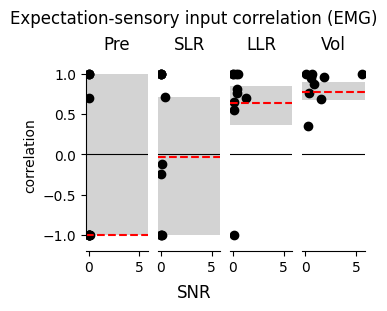

In [22]:
df_corr_emg = pd.read_csv(os.path.join(ROOT,'data', 'correlations', 'correlations.EMG.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(epochs), sharex=True, sharey=True, figsize=(3.5, 3), constrained_layout=True)

for e, epoch in enumerate(epochs):
    ax = axs[e]
    df_corr_tmp = df_corr_emg[(df_corr_emg['epoch'] == epoch)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{epoch}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if e == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(epoch)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (EMG)')

plt.show()


SMA: r=-0.9999999999906444, [-1.0, -0.9999999966345332]
PMd: r=-0.9999999999999182, [-1.0, -0.9999999977243712]
PMv: r=-0.999999999999805, [-0.9999999999999996, -0.99999997026955]
M1: r=-0.8232093652196346, [-1.0, -0.6850746790071263]
S1: r=-0.6134584479664559, [-0.9327735814642816, -0.536031432583643]
SPLa: r=-0.9999999999998316, [-0.9999999999999551, -0.9999999829220148]
SPLp: r=-0.9999999923223722, [-0.9999999999999736, -0.9999999973893466]


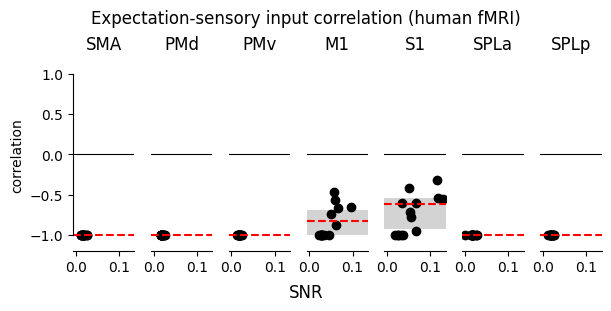

In [20]:
df_corr_bold = pd.read_csv(os.path.join(ROOT, 'data', 'correlations', 'correlations.BOLD.tsv'), sep='\t')
corr = 'cue-finger'
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(6, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    df_corr_tmp = df_corr_bold[(df_corr_bold['roi'] == roi) & (df_corr_bold['Hem'] == H) & (df_corr_bold['corr'] == corr)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{roi}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if r == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (human fMRI)')

plt.show()


alpha: r=0.0719297874477002, [-0.4319165941513781, 0.7791305428824261]
beta: r=-0.7628800845598983, [-1.0, -0.3595200059340832]
gamma: r=-0.9469992443210224, [-1.0, -0.6589124701488683]


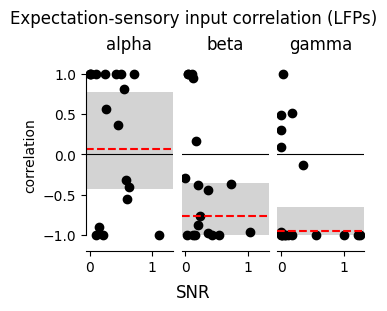

In [19]:
df_corr_lfp = pd.read_csv(os.path.join(ROOT, 'data', 'correlations', 'correlations.lfp.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(freqs), sharex=True, sharey=True, figsize=(3.5, 3), constrained_layout=True)

for f, freq in enumerate(freqs):
    ax = axs[f]
    df_corr_tmp = df_corr_lfp[(df_corr_lfp['freq'] == freq)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{freq}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if f == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(freq)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input correlation (LFPs)')

plt.show()


early: r=0.4074837857934948, [0.2807946587534991, 0.5032685913852967]
late: r=0.3208748054254555, [0.1548391021522324, 0.5182783870779073]


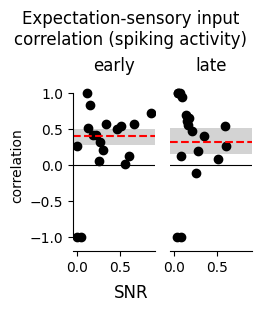

In [17]:
df_corr_spk = pd.read_csv(os.path.join(ROOT, 'data', 'correlations', 'correlations.spk.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(time_interval), sharex=True, sharey=True, figsize=(2.5, 3), constrained_layout=True)

for t, ti in enumerate(time_interval):
    ax = axs[t]
    df_corr_tmp = df_corr_spk[(df_corr_spk['time_interval'] == ti)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{ti}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if t == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(ti)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Expectation-sensory input\ncorrelation (spiking activity)')

plt.show()
